Predikcija zapošljavanja kandidata
Opis: Na osnovu veštački generisanih podataka o kandidatima (godine, obrazovanje, iskustvo, veštine, sertifikati, poznavanje jezika, uspešnost na testovima), klasifikuj da li bi kandidat bio "zaposlen" ili "odbijen".

Modeli: Logistic Regression, Random Forest, XGBoost

Izazovi: balans klase, inženjering karakteristika (veštine, jezici kao one-hot)

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df = pd.read_csv('candidate_dataset.csv')


In [4]:
print(df.head())

   age education_level  experience_years  num_certificates english_level  \
0   56        bachelor                40                 0  intermediate   
1   46        bachelor                25                 4         basic   
2   32         primary                10                 4         basic   
3   60          master                40                 1      advanced   
4   25        bachelor                 5                 1      advanced   

   score_test  has_recommendation city_size  hired  
0   60.318529                   1    medium      0  
1   82.137814                   1     large      1  
2   20.715025                   0     small      0  
3   78.842604                   0     large      1  
4   70.394444                   0     large      0  


In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 10000 non-null  int64  
 1   education_level     10000 non-null  object 
 2   experience_years    10000 non-null  int64  
 3   num_certificates    10000 non-null  int64  
 4   english_level       10000 non-null  object 
 5   score_test          10000 non-null  float64
 6   has_recommendation  10000 non-null  int64  
 7   city_size           10000 non-null  object 
 8   hired               10000 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 703.3+ KB
None


In [6]:
print(df.describe())

              age  experience_years  num_certificates    score_test  \
count  10000.0000      10000.000000      10000.000000  10000.000000   
mean      39.0020         20.887800          1.477800     64.902722   
std       12.2858         12.286884          1.210642     15.050039   
min       18.0000          0.000000          0.000000     13.679306   
25%       29.0000         10.000000          1.000000     54.838249   
50%       39.0000         21.000000          1.000000     65.013936   
75%       50.0000         31.000000          2.000000     75.272357   
max       60.0000         40.000000          9.000000    100.000000   

       has_recommendation         hired  
count        10000.000000  10000.000000  
mean             0.403900      0.380000  
std              0.490702      0.485411  
min              0.000000      0.000000  
25%              0.000000      0.000000  
50%              0.000000      0.000000  
75%              1.000000      1.000000  
max              1.00000

In [7]:
print(df['hired'].value_counts(normalize=True))

hired
0    0.62
1    0.38
Name: proportion, dtype: float64


Distribucija numerickih karakteristika:

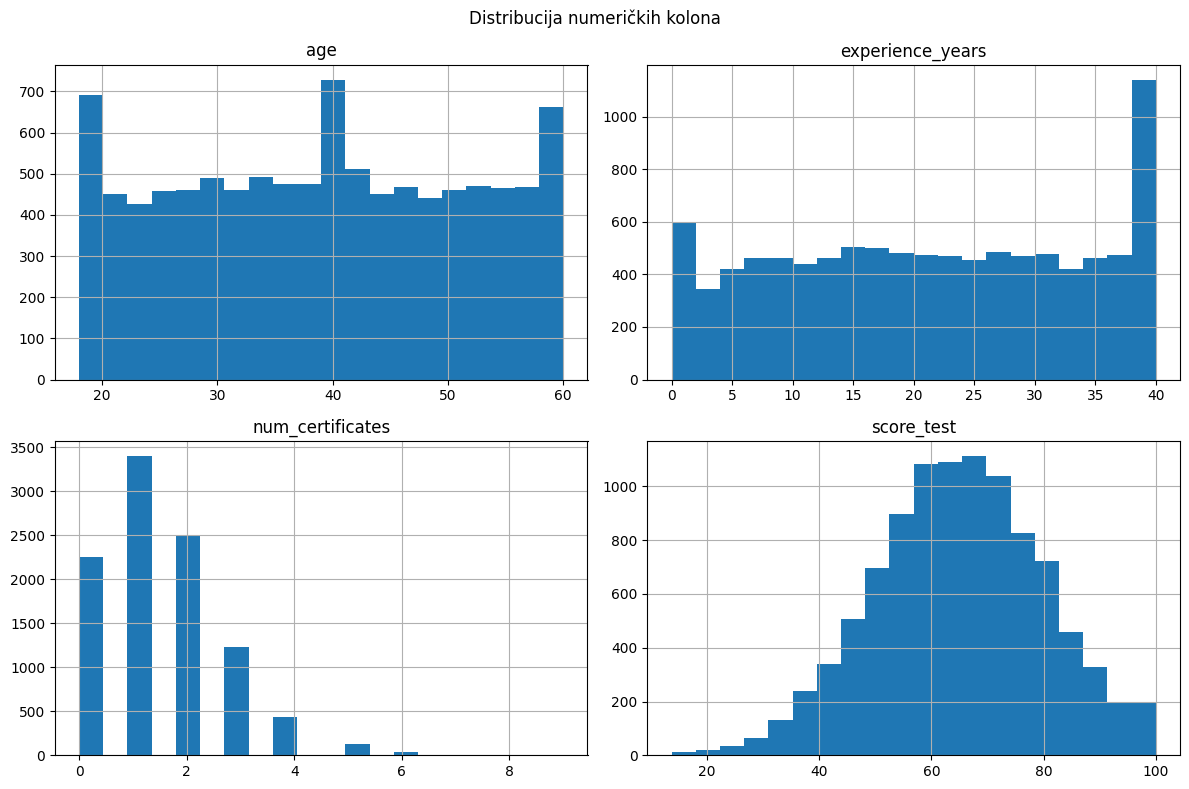

In [8]:
num_cols = ['age', 'experience_years', 'num_certificates', 'score_test']
df[num_cols].hist(bins=20, figsize=(12, 8), layout=(2, 2))
plt.suptitle("Distribucija numeričkih kolona")
plt.tight_layout()
plt.show()

Distribucija kategorijalnih karakteristika

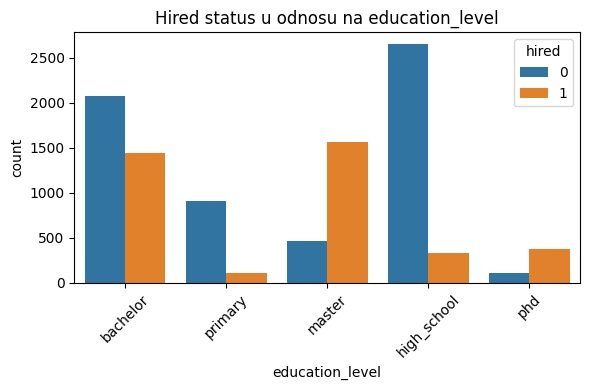

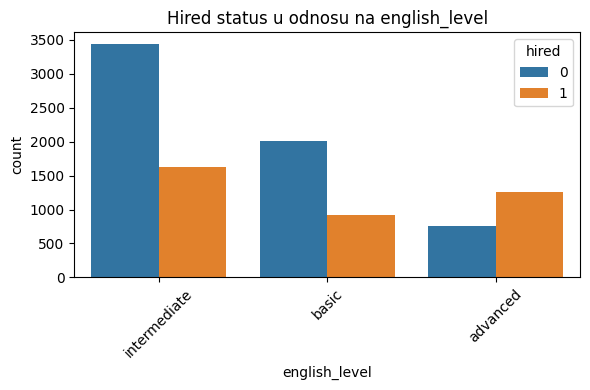

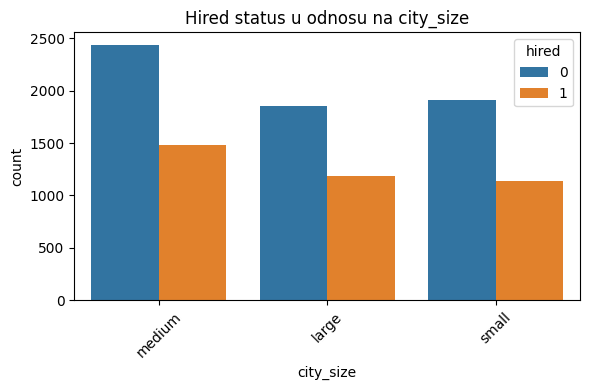

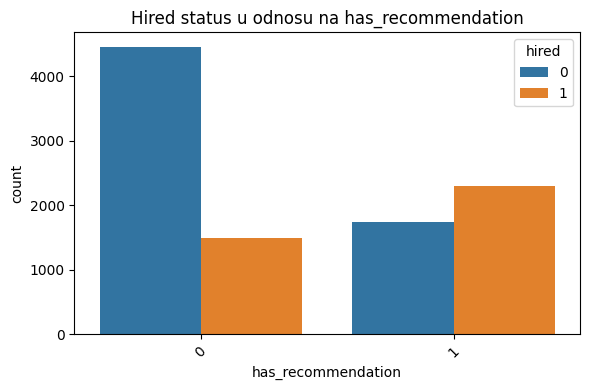

In [9]:
cat_cols = ['education_level', 'english_level', 'city_size', 'has_recommendation']
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue='hired')
    plt.title(f"Hired status u odnosu na {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Korelacija numerickih varijabli sa "hired"

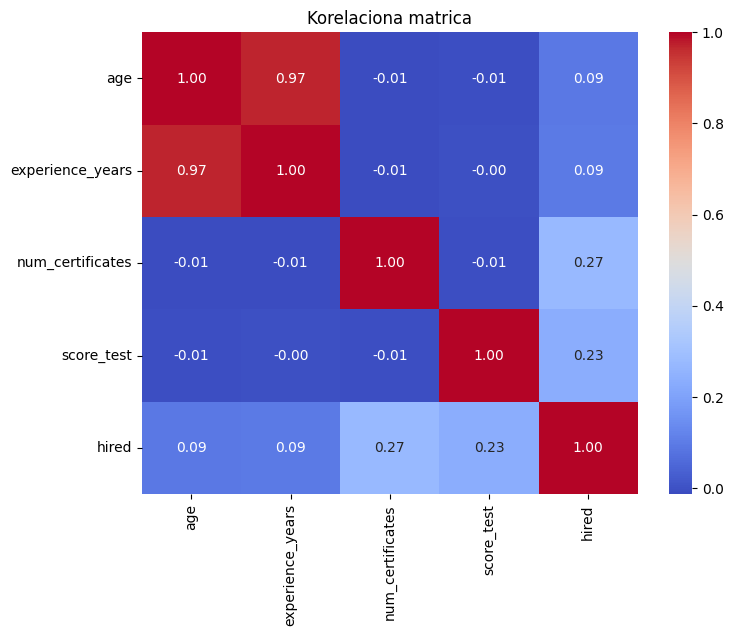

In [10]:
corr = df[num_cols + ['hired']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Korelaciona matrica")
plt.show()


Pivot tabela:

In [11]:
print(df.groupby('hired')[['age', 'experience_years', 'score_test', 'num_certificates']].mean())


             age  experience_years  score_test  num_certificates
hired                                                           
0      38.130484         19.980000   62.148391          1.218387
1      40.423947         22.368947   69.396631          1.901053


Koristimo One-Hot Encoding jer sve kategorijalne promenljive nemaju redosled.

Koristimo StandardScaler za normalizaciju numeričkih kolona.


Koristimo train_test_split sa npr. 80/20 podelom.



In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_prepared = df.copy()

# One-hot encoding kategorijalnih kolona
df_prepared = pd.get_dummies(df_prepared, columns=['education_level', 'english_level', 'city_size'], drop_first=True)

# Skaliranje numerickih kolona
scaler = StandardScaler()
numerical_cols = ['age', 'experience_years', 'num_certificates', 'score_test']
df_prepared[numerical_cols] = scaler.fit_transform(df_prepared[numerical_cols])

# Target i feature matrica
X = df_prepared.drop('hired', axis=1)
y = df_prepared['hired']

# Podela na trening i test skup (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Provera dimenzija
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribucija:", y_train.value_counts(normalize=True))
print("y_test distribucija:", y_test.value_counts(normalize=True))


X_train shape: (8000, 13)
X_test shape: (2000, 13)
y_train distribucija: hired
0    0.62
1    0.38
Name: proportion, dtype: float64
y_test distribucija: hired
0    0.62
1    0.38
Name: proportion, dtype: float64


Treniranje modela:

In [13]:
#Random forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Treniranje modela
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predikcija
y_pred = rf.predict(X_test)

# Evaluacija
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("\n=== Accuracy Score ===")
print(f"{accuracy_score(y_test, y_pred):.4f}")


=== Confusion Matrix ===
[[1234    6]
 [  10  750]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1240
           1       0.99      0.99      0.99       760

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000


=== Accuracy Score ===
0.9920


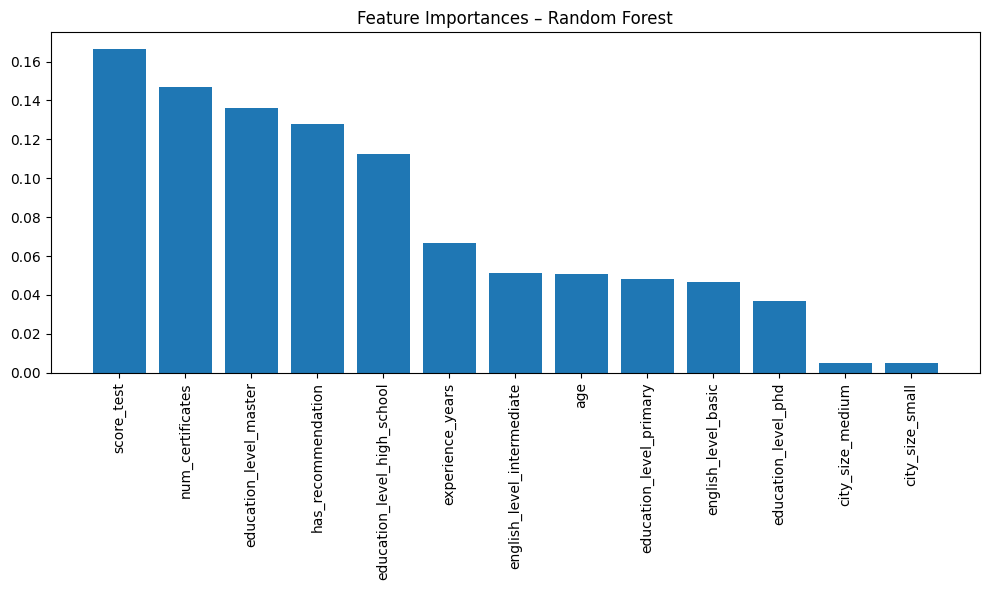

In [14]:
# Feature importance za random forest model:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importances – Random Forest")
plt.bar(range(len(features)), importances[indices])
plt.xticks(range(len(features)), [features[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()


Model logisticke regresije:

In [15]:
from sklearn.linear_model import LogisticRegression

# Treniranje
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Predikcija
y_pred_lr = lr.predict(X_test)

# Evaluacija
print("\n=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))



=== Logistic Regression ===
Accuracy: 0.893
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      1240
           1       0.86      0.85      0.86       760

    accuracy                           0.89      2000
   macro avg       0.89      0.88      0.89      2000
weighted avg       0.89      0.89      0.89      2000



Model xgboost

In [26]:
from xgboost import XGBClassifier

# Treniranje
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

# Predikcija
y_pred_xgb = xgb.predict(X_test)

# Evaluacija
print("\n=== XGBoost Classifier ===")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))



=== XGBoost Classifier ===
Accuracy: 0.998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1240
           1       1.00      1.00      1.00       760

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:19:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Poredjenje rezultata sva tri modela:


In [17]:
models = {
    "Random Forest": (y_test, y_pred),
    "Logistic Regression": (y_test, y_pred_lr),
    "XGBoost": (y_test, y_pred_xgb)
}

for name, (true, pred) in models.items():
    acc = accuracy_score(true, pred)
    print(f"{name} Accuracy: {acc:.4f}")


Random Forest Accuracy: 0.9920
Logistic Regression Accuracy: 0.8930
XGBoost Accuracy: 0.9980


Cross-validation nam omogućava da proverimo kako se model ponaša na različitim delovima skupa podataka i time dobijemo stabilniju procenu performansi.

Koristićemo Stratified K-Fold Cross-Validation (da sačuvamo proporciju klasa) i izračunati prosečan accuracy za svaki model.

In [18]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# K-Fold konfiguracija
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest
rf_cv_scores = cross_val_score(rf, X, y, cv=cv, scoring='accuracy')
print("Random Forest CV Accuracy:", rf_cv_scores)
print("Random Forest Mean Accuracy: {:.4f}".format(rf_cv_scores.mean()))

# Logistic Regression
lr_cv_scores = cross_val_score(lr, X, y, cv=cv, scoring='accuracy')
print("\nLogistic Regression CV Accuracy:", lr_cv_scores)
print("Logistic Regression Mean Accuracy: {:.4f}".format(lr_cv_scores.mean()))

# XGBoost
xgb_cv_scores = cross_val_score(xgb, X, y, cv=cv, scoring='accuracy')
print("\nXGBoost CV Accuracy:", xgb_cv_scores)
print("XGBoost Mean Accuracy: {:.4f}".format(xgb_cv_scores.mean()))


Random Forest CV Accuracy: [0.9905 0.9925 0.993  0.993  0.9945]
Random Forest Mean Accuracy: 0.9927

Logistic Regression CV Accuracy: [0.8975 0.911  0.9075 0.916  0.9085]
Logistic Regression Mean Accuracy: 0.9081


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:51:56] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:51:56] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:51:56] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:51:56] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost CV Accuracy: [0.9995 0.9985 0.9985 0.999  0.9975]
XGBoost Mean Accuracy: 0.9986


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:51:57] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


ROC & AUC

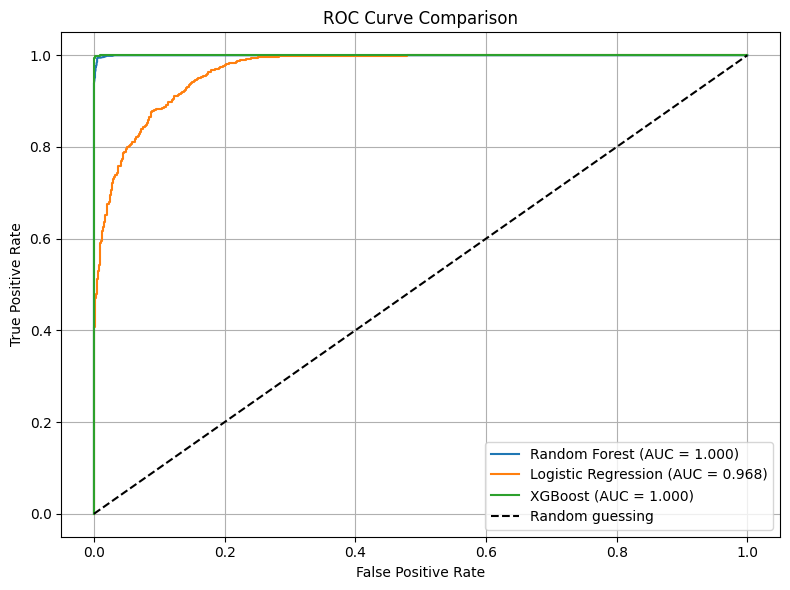

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Potrebni su predikovani *verovatnosni* rezultati, ne klase
y_proba_rf = rf.predict_proba(X_test)[:, 1]
y_proba_lr = lr.predict_proba(X_test)[:, 1]
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# Računanje ROC krive i AUC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

auc_rf = auc(fpr_rf, tpr_rf)
auc_lr = auc(fpr_lr, tpr_lr)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Crtanje ROC kriva
plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guessing')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


Primer pogresno klasifikovanih

In [20]:
# Prikaz pogrešno klasifikovanih primera
wrong_preds = X_test.copy()
wrong_preds['true_label'] = y_test.values
wrong_preds['predicted'] = y_pred

# Filtriraj gde je predikcija pogrešna
misclassified = wrong_preds[wrong_preds['true_label'] != wrong_preds['predicted']]

# Prikaz prvih 10 pogrešnih primera
print("Prvih 10 pogrešno klasifikovanih primera (Random Forest):")
print(misclassified.head(10))


Prvih 10 pogrešno klasifikovanih primera (Random Forest):
           age  experience_years  num_certificates  score_test  \
4232 -1.383943         -1.293135          0.431363   -2.021351   
6313 -1.465342         -1.618701         -0.394686    2.332156   
4002 -1.139747         -1.293135          1.257412    0.192344   
7949 -1.628140         -1.700093          0.431363   -0.610434   
2459 -0.407157         -0.723393          0.431363    0.338713   
1941 -1.465342         -1.700093          1.257412    0.473113   
9611 -1.465342         -1.293135         -0.394686   -2.726974   
2056 -1.058348         -1.293135         -1.220736   -1.736190   
1225 -0.895550         -1.293135          1.257412   -0.131825   
6417 -1.383943         -1.211743          0.431363   -0.567251   

      has_recommendation  education_level_high_school  education_level_master  \
4232                   0                        False                   False   
6313                   1                        False

Grid Search

In [22]:
from sklearn.model_selection import GridSearchCV

# Definisanje prostora hiperparametara
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Inicijalizacija modela
rf_base = RandomForestClassifier(random_state=42)

# Grid search sa 5-fold cross-validation
grid_search_rf = GridSearchCV(estimator=rf_base, param_grid=param_grid,
                              scoring='accuracy', cv=5, n_jobs=-1, verbose=1)

# Treniranje
grid_search_rf.fit(X_train, y_train)

# Najbolji rezultati
print("Najbolji parametri:", grid_search_rf.best_params_)
print("Najbolji rezultat (CV Accuracy):", grid_search_rf.best_score_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Najbolji parametri: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Najbolji rezultat (CV Accuracy): 0.99175


Evaluacija najboljeg modela na test

In [23]:
# Evaluacija na test skupu
best_rf = grid_search_rf.best_estimator_
y_best_pred = best_rf.predict(X_test)

print("\n=== Evaluacija najboljeg RF modela na test skupu ===")
print("Accuracy:", accuracy_score(y_test, y_best_pred))
print(classification_report(y_test, y_best_pred))



=== Evaluacija najboljeg RF modela na test skupu ===
Accuracy: 0.992
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1240
           1       0.99      0.99      0.99       760

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



cuvanje modela


In [24]:
import joblib

# Cuvanje modela
joblib.dump(best_rf, "best_rf_model.pkl")
print("Model je uspešno sačuvan kao 'best_rf_model.pkl'")


Model je uspešno sačuvan kao 'best_rf_model.pkl'


Za potrebe kasnijeg ucitavanja modela

In [25]:
# load modela
loaded_model = joblib.load("best_rf_model.pkl")

# Testiranje ucitanog modela
y_loaded_pred = loaded_model.predict(X_test)
print("Accuracy učitanog modela:", accuracy_score(y_test, y_loaded_pred))


Accuracy učitanog modela: 0.992
